# Kohisevan prosessianturisignaalin kohinanpoisto PROC LOESS -proseduurilla

## Yhteenveto

Tuotantolinjan uunin kammion lämpötila-anturia näytteistetään kerran sekunnissa käynnistyksen aikana, joten jokainen lukema sekoittaa hitaan epälineaarisen lämpötilasiirtymän (nopea lämpenemisrampi, asettumisen ylitys ja sitten paluu kohti 300 °C:n asetusarvoa) huomattavaan mittauskohinaan. Tämä muistikirja käyttää **PROC LOESS** -proseduuria taustalla olevan signaalin palauttamiseen ei-parametrisesti. 100 näytteen lokissa AICC valitsi tasoitusparametriksi 0,08 (8 vastaavaa parametria); tuloksena syntyvä käyrä seuraa piilevää signaalia tarkasti, jättäen jäännöksiin 3,10 °C:n keskihajonnan — käytännössä syöttämämme 4 °C:n kohinan, vähennettynä sovituksen selittämällä varianssilla. Tunnettuun todelliseen signaaliin verrattuna LOESS-estimaatti laskee neliövirheen keskiarvon 14,77:stä (raaka) 6,63:een, ja SCORE-vaihe näytteistää kohinanpoistetun signaalin uudelleen tasavälille seurantaverkolle myöhempää tilastollista prosessinohjausta varten.

## Tietolähteet

| Aineisto | Rivit | Muuttujat | Kuvaus |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t` (kulunut aika sekunteina, 0–99), `temp` (havaittu kammion lämpötila, °C), `truth` (piilevä kohinaton signaali, vain validointiin) | Synteettinen uunin anturiloki, yksi näyte sekunnissa. Piilevä signaali on nopea lämpenemisrampi kohti 300 °C:n asetusarvoa, jossa on vaimennettu ylitys, joka huippuaa lähellä t = 28 (~295 °C), laskee ja asettuu takaisin kohti asetusarvoa; havaittu `temp` lisää Gaussista mittauskohinaa (keskihajonta ~4 °C). |
| `grid` | 60 | `t` (tasavälinen 0–99 seurantaverkko) | Säännöllinen aikaverkko, jota SCORE-lauseke käyttää tasavälisen kohinanpoistetun signaalin tuottamiseen SPC-kaaviota varten. |

Tuotantolinjalla uunin kammion anturi kirjaa lämpötilan kerran sekunnissa käynnistyksen aikana. Tallentamamme lukema on **todellinen lämpötila plus mittauskohina**. Todellinen tila ei noudata mitään siistiä parametrista kaavaa — se nousee lämpenemisen aikana, ylittää asetusarvon ja asettuu sitten — joten globaali lineaarinen tai polynominen sovitus olisi huono malli.

**Paikallinen regressio (LOESS)** on oikea työkalu: se sovittaa matala-asteisia polynomeja liukuviin paikallisiin naapurustoihin ja palauttaa mielivaltaisen tasaisen signaalin ilman, että meidän tarvitsee määrittää sen funktionaalista muotoa. Tässä me:

1. Simuloimme realistisen kohisevan 100 näytteen anturilokin.
2. Annamme `PROC LOESS` -proseduurin valita oman tasoituskaistanleveytensä AICC-kriteerillä.
3. Liitämme sovitettuun signaaliin 95 %:n luottamusvälin.
4. Pisteytämme mallin säännöllisellä verkolla myöhempää SPC:tä varten.
5. Määritämme, kuinka paljon kohinaa poistimme.

## Vaihe 1 — Anturilokin simulointi

Luomme 100 näytettä välille 0–99 sekuntia. Piilevä signaali `truth` on nopea lämpenemisrampi kohti 300 °C:n asetusarvoa, jossa on vaimennettu ylitys — muoto, jota mikään suora viiva tai yksittäinen polynomi ei tavoita hyvin: se nousee jyrkästi, huippuaa asetusarvon yläpuolella lähellä t = 28, laskee ja asettuu sitten takaisin. Havaittu `temp` lisää Gaussista mittauskohinaa. `call streaminit` kiinnittää siemenluvun, jotta ajo on toistettavissa.

In [1]:
TIEDOT sensor;
    CALL streaminit(70421);
    setpoint = 300;
    TEE t = 0 ASTI 99;
        /* Piilevä signaali: nopea lämpenemisrampi + vaimennettu asettumisen ylitys */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Havaittu lukema = todellinen + mittauskohina (keskihajonta ~4 C) */
        TEMP = truth + rand('NORMAL', 0, 4);
        TULOSTE;
    LOPPU;
    SÄILYTÄ t TEMP truth;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=sensor(obs=8) noobs NIMIKE;
    NIMIKE t='Aika (s)' TEMP='Lämpötila (C)' truth='Todellinen signaali (C)';
    OTSIKKO 'Ensimmäiset 8 anturinäytettä';
SUORITA;

                                              Ensimmäiset 8 anturinäytettä                                              

Aika (s)    Lämpötila (C)  Todellinen signaali (C)
       0     0.1684867131                        0
       1    28.1933107495            32.0778466448
       2    61.6123615699            61.2117857105
       3    85.5053781561             87.643846097
       4   110.5560474248           111.5945193774
       5   136.6368358359           133.2650493509
       6   144.2434193147           152.8394750856
       7   177.8286488692           170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Vaihe 2 — Raakasignaalin tarkastelu

Nopea hajontakaavio näyttää ongelman: taustalla oleva ajautuma on silmin selvä, mutta se on hautautunut näytteestä toiseen vaihtelevaan kohinaan. Tarvitsemme arvion tasaisesta käyrästä, emme hyppelehtiviä pisteitä.

                                              Ensimmäiset 8 anturinäytettä                                              




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


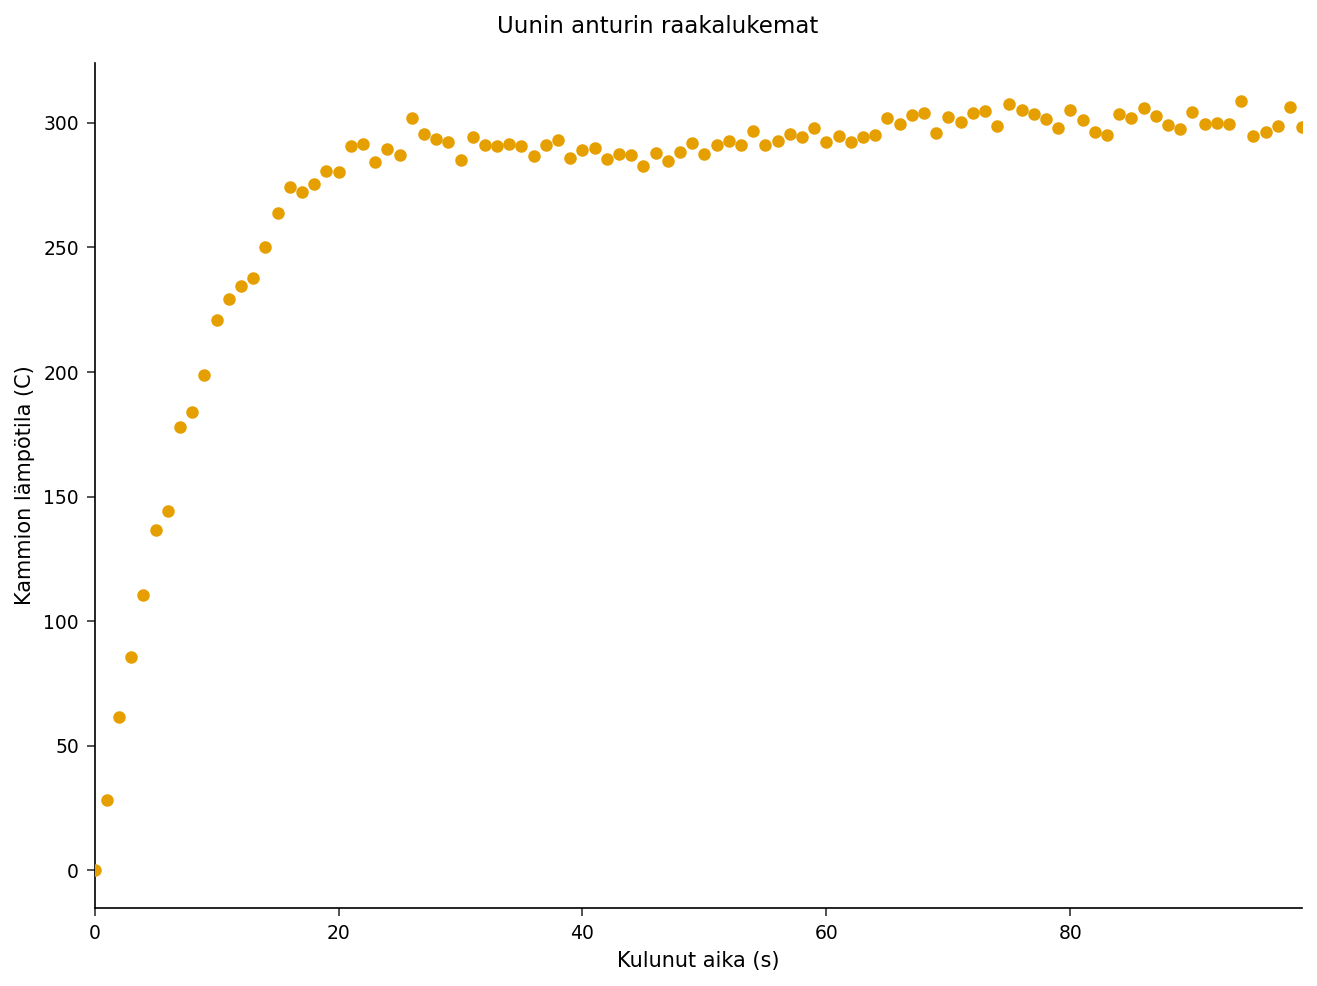

In [2]:
ODS GRAPHICS ON;

PROSEDUURI SGPLOT TIEDOT=sensor;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS NIMIKE='Kulunut aika (s)';
    YAXIS NIMIKE='Kammion lämpötila (C)';
    OTSIKKO 'Uunin anturin raakalukemat';
SUORITA;

ODS GRAPHICS OFF;

## Vaihe 3 — LOESS-sovitus automaattisella kaistanleveyden valinnalla

Tasoitusparametri määrää, kuinka leveä kukin paikallinen naapurusto on: liian pieni ylisovittaa kohinan, liian suuri pyyhkii ylityksen pois. Sen sijaan että arvaisimme, annamme LOESS:n valita sen minimoimalla **korjatun Akaiken informaatiokriteerin** komennolla `select=AICC`. Käytämme paikallisia toisen asteen polynomeja (`degree=2`), jotta käyrä voi seurata lämpenemisen ja ylityksen kaarevuutta, ja pyydämme 95 %:n luottamusväliä komennoilla `clm` ja `alpha=0.05`.

`ODS OUTPUT` tallentaa kaksi taulukkoa aineistoiksi: `OutputStatistics` (pistekohtaiset tasoitetut arvot ja jäännökset) ja `FitSummary` (valittu kaistanleveys ja sovinnan diagnostiikka). `OUTPUT`-lauseke kirjoittaa `fitted`-aineiston, jossa on ennuste, jäännös ja 95 %:n luottamusrajat jokaiselle havainnolle — raaka-aine seuraaville kuvaajille.

In [3]:
PROSEDUURI loess TIEDOT=sensor;
    ODS OUTPUT OutputStatistics=loess_fit
               FitSummary=fit_summary;
    MODEL TEMP = t / DEGREE=2 select=AICC CLM ALPHA=0.05 details;
    TULOSTE out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
SUORITA;

                                              Ensimmäiset 8 anturinäytettä                                              


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Vaihe 4 — Valitun mallin tarkastelu

Fit Summary -taulukko tallentaa AICC-optimaalisen tasoitusparametrin ja ennustematriisin jäljen (efektiiviset vapausasteet — mallin monimutkaisuuden mitta). Pienempi tasoitusparametri ja suurempi vapausasteluku tarkoittavat mutkittelevampaa sovitusta; AICC tasapainottaa sovituksen ja monimutkaisuuden automaattisesti.

In [4]:
PROSEDUURI TULOSTA TIEDOT=fit_summary noobs NIMIKE;
    OTSIKKO 'LOESS-sovituksen yhteenveto (AICC-valittu kaistanleveys)';
SUORITA;

                                LOESS-sovituksen yhteenveto (AICC-valittu kaistanleveys)                                

SMOOTHINGPARAMETER                           LABEL1         NVALUE1
              0.08  Residual Sum of Squares          950.8591917253
              0.08  Equivalent Number of Parameters               8
              0.08  Delta1                                        8
              0.08  Delta2                                      7.6
              0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Vaihe 5 — Sovituksen ja luottamusvälin vertailu todelliseen signaaliin

Koska kyseessä on simuloitu data, säilytimme kohinattoman `truth`-sarakkeen. LOESS-estimaatin ja sen 95 %:n välin piirtäminen `truth`-sarakkeen rinnalle näyttää, kuinka uskollisesti tasoitin palautti piilevän signaalin, jota se ei koskaan suoraan nähnyt.

                                LOESS-sovituksen yhteenveto (AICC-valittu kaistanleveys)                                




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


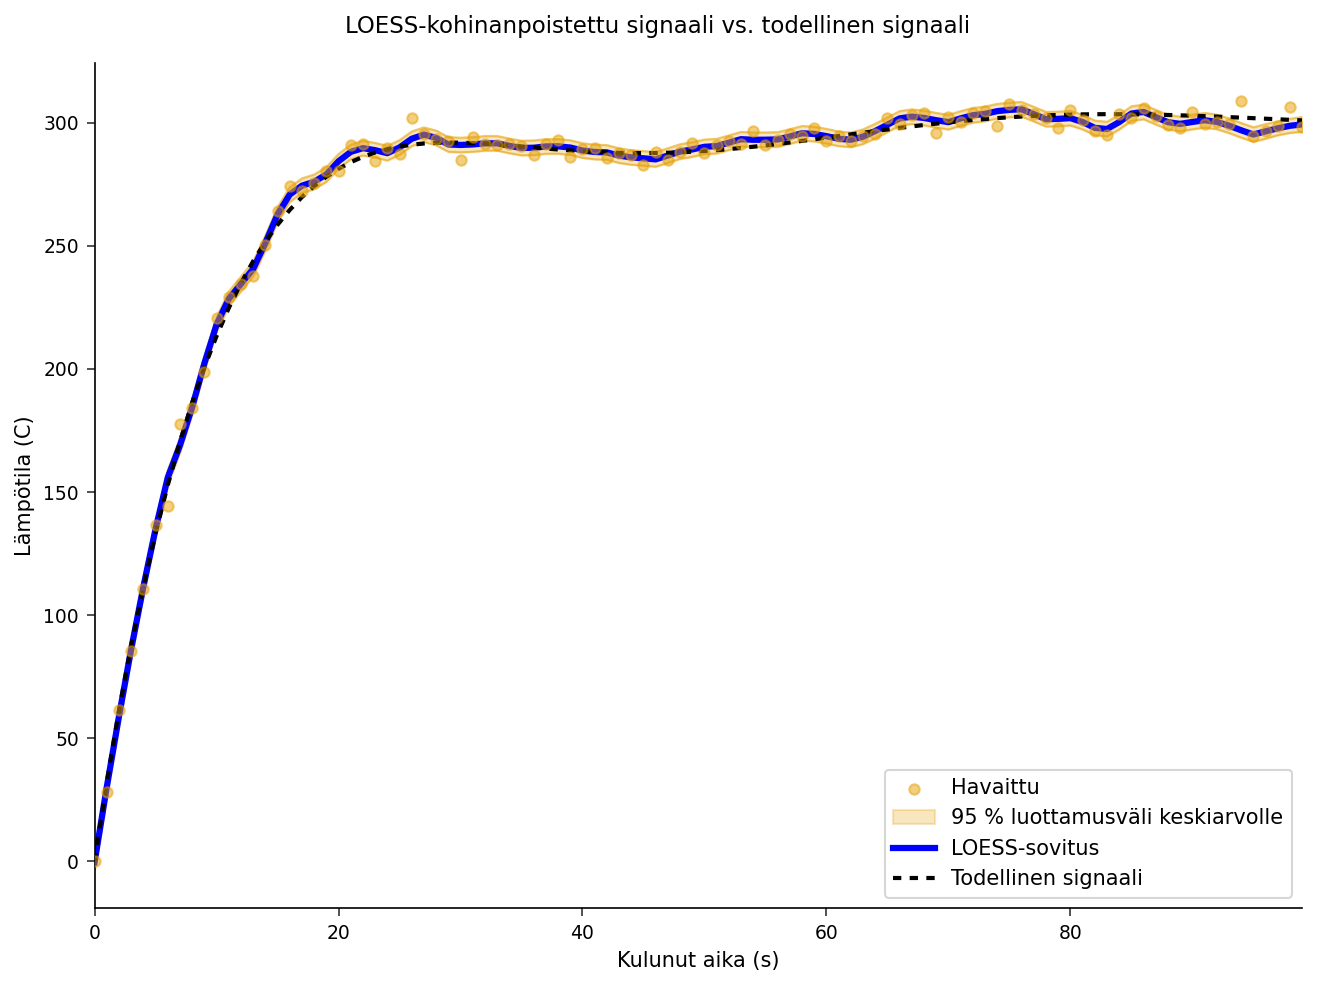

In [5]:
PROSEDUURI LAJITTELE TIEDOT=fitted; MUKAAN t; SUORITA;

ODS GRAPHICS ON;

PROSEDUURI SGPLOT TIEDOT=fitted;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='Havaittu';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='95 % luottamusväli keskiarvolle';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='LOESS-sovitus';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='Todellinen signaali';
    XAXIS NIMIKE='Kulunut aika (s)';
    YAXIS NIMIKE='Lämpötila (C)';
    OTSIKKO 'LOESS-kohinanpoistettu signaali vs. todellinen signaali';
SUORITA;

ODS GRAPHICS OFF;

## Vaihe 6 — Jäännösdiagnostiikka

Jäännösten (havaittu miinus sovitettu) tulisi näyttää rakenteettomalta, nollan ympärille keskittyneeltä kohinalta. Jäljelle jäävä trendi viittaisi alitasoitukseen tai huomaamatta jääneeseen piirteeseen. Piirrämme jäännökset ajan funktiona ja teemme yhteenvedon niiden hajonnasta — jäännösten keskihajonnaksi tulee 3,10 °C, hieman alle syöttämämme 4 °C:n kohinan, koska paikallinen sovitus imee siitä pienen osan.

                                LOESS-sovituksen yhteenveto (AICC-valittu kaistanleveys)                                

                                     Jäännösten yhteenveto (havaittu mittauskohina)                                     

                                                  The MEANS Procedure

 Variable  Label                  N        Mean     Std Dev     Minimum     Maximum
 ----------------------------------------------------------------------------------
 RESID     Jäännös (C)          100       0.139       3.096     -11.688      11.909
 ----------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


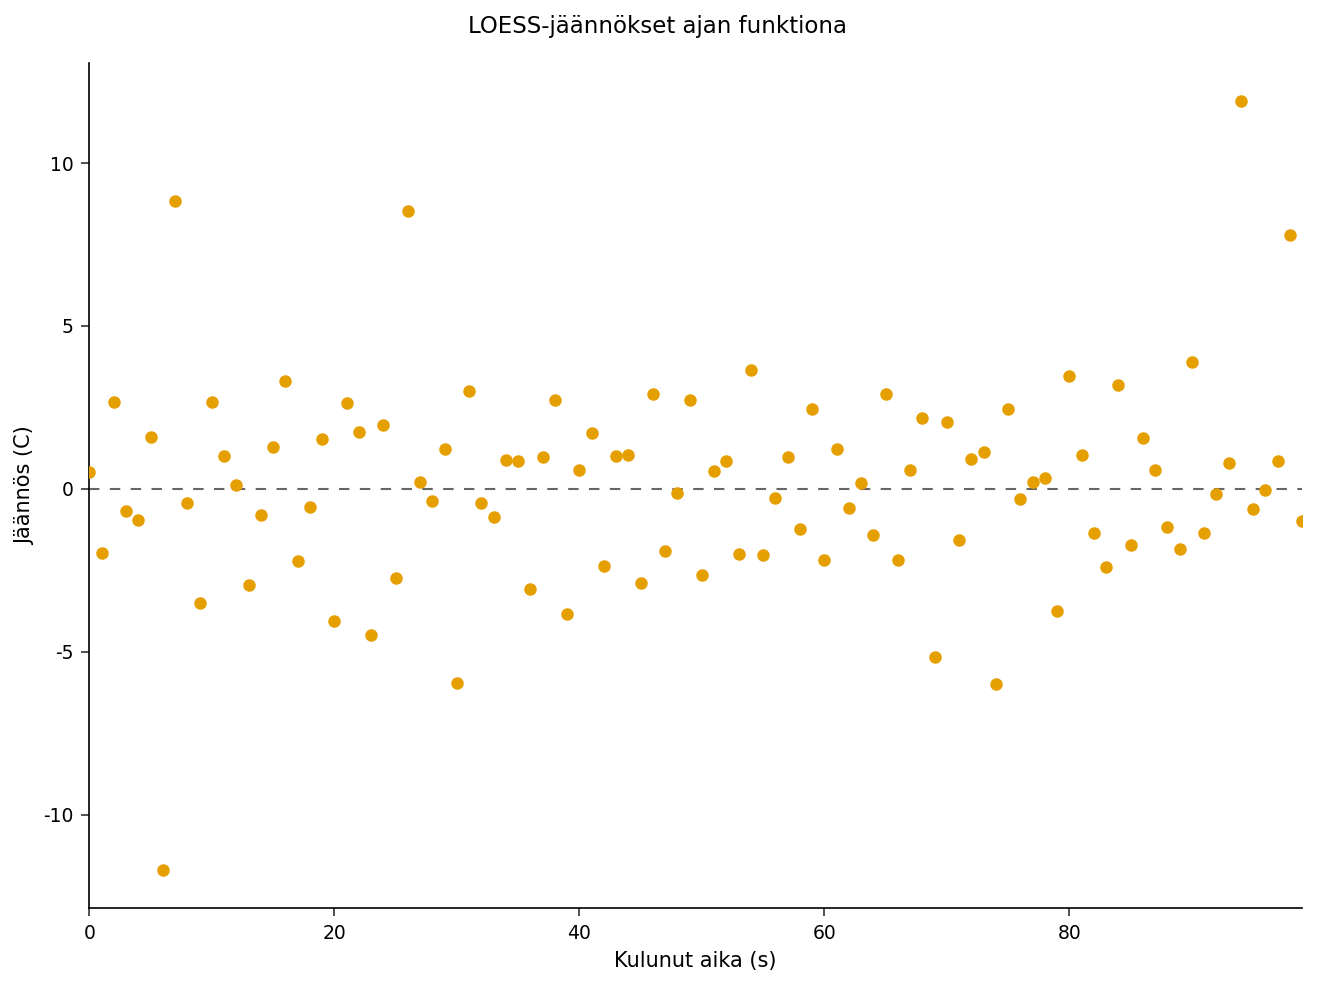

In [6]:
ODS GRAPHICS ON;

PROSEDUURI SGPLOT TIEDOT=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS NIMIKE='Kulunut aika (s)';
    YAXIS NIMIKE='Jäännös (C)';
    OTSIKKO 'LOESS-jäännökset ajan funktiona';
SUORITA;

ODS GRAPHICS OFF;

PROSEDUURI KESKIARVOT TIEDOT=fitted n mean std MIN MAX maxdec=3;
    MUUTTUJA resid;
    NIMIKE resid='Jäännös (C)';
    OTSIKKO 'Jäännösten yhteenveto (havaittu mittauskohina)';
SUORITA;

## Vaihe 7 — Säännöllisen seurantaverkon pisteytys SPC:tä varten

Anturin aikaleimojen ei tarvitse olla tasavälisiä, mutta ohjauskaavio haluaa signaalin kiinteällä tahdilla. Rakennamme tasavälisen 60 pisteen aikaverkon ja sovellamme siihen sovitettua LOESS-mallia `SCORE`-lausekkeella, pyytäen luottamusrajoja. Pisteytetyt arvot ovat siisti, tasavälinen signaali, joka on valmis syötettäväksi SPC-rutiiniin.

In [7]:
TIEDOT grid;
    TEE t = 0 ASTI 99 by 99/59;
        TULOSTE;
    LOPPU;
SUORITA;

PROSEDUURI loess TIEDOT=sensor;
    MODEL TEMP = t / DEGREE=2 select=AICC CLM ALPHA=0.05;
    SCORE TIEDOT=grid CLM print;
    OTSIKKO 'LOESS pisteytettynä tasavälisellä seurantaverkolla';
SUORITA;

                                     Jäännösten yhteenveto (havaittu mittauskohina)                                     


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Vaihe 8 — Kohinanpoiston määrittäminen

Lopuksi vertaamme raakasignaalia ja LOESS-estimaattia tunnettuun totuuteen. Tasoitetun signaalin neliövirheen keskiarvon tulisi olla huomattavasti pienempi kuin raakalukemien, mikä vahvistaa, että LOESS poisti mittauskohinan säilyttäen samalla lämpenemisrampin ja ylityksen.

In [8]:
TIEDOT accuracy;
    ASETA fitted;
    raw_sq_err   = (TEMP     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=accuracy mean maxdec=3;
    MUUTTUJA raw_sq_err loess_sq_err;
    NIMIKE raw_sq_err   = 'Raakalukemien MSE suhteessa totuuteen'
          loess_sq_err = 'LOESS-sovituksen MSE suhteessa totuuteen';
    OTSIKKO 'Kohinanpoiston suorituskyky: raaka vs. LOESS';
SUORITA;

                                      Kohinanpoiston suorituskyky: raaka vs. LOESS                                      

                                                  The MEANS Procedure

 Variable      Label                                              Mean
 ---------------------------------------------------------------------
 raw_sq_err    Raakalukemien MSE suhteessa totuuteen            14.774
 loess_sq_err  LOESS-sovituksen MSE suhteessa totuuteen          6.629
 ---------------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Tulosten tulkinta

- **Automaattinen kaistanleveys.** `select=AICC` valitsi tasoitusparametriksi **0,08** ilman manuaalista säätöä, mikä vastaa noin **8:aa vastaavaa parametria** — riittävästi paikallista joustavuutta seuraamaan lämpenemistä, ylitystä ja notkahdusta, samalla tasoittaen kohinan yli.
- **Uskollinen palautus.** Sovitettu käyrä seuraa piilevää `truth`-signaalia tarkasti rampin, lähellä t = 28 olevan ylityshuipun ja asettumishännän yli, mikä osoittaa, että LOESS palautti mielivaltaisen epälineaarisen signaalin ilman parametrisia oletuksia.
- **Puhtaat jäännökset.** Jäännökset hajaantuvat nollan ympärille keskihajonnalla **3,10 °C** (keskiarvo 0,14, vaihteluväli −11,7–11,9) eivätkä osoita jäljellä olevaa aikatrendiä — todiste siitä, ettei malli ole yli- eikä alitasoitettu.
- **Mitattava kohinanpoisto.** Verrattuna todelliseen signaaliin LOESS-estimaatti laskee neliövirheen keskiarvon **14,77:stä** (raakalukemat) **6,63:een** — 55 %:n vähennys, prosessinvalvonnan keskeinen hyöty.
- **SPC-valmis tuloste.** SCORE-vaihe tuotti kohinanpoistetun signaalin tasavälisellä 60 pisteen verkolla luottamusrajoineen, juuri siinä muodossa, jota myöhempi ohjauskaavio käyttää.

**Yhteenveto:** Kun prosessianturi tuottaa tasaisen mutta kohisevan, tuntemattoman muodon signaalin, PROC LOESS on vähäoletuksinen, itsesäätyvä tapa erottaa taustalla oleva trendi, liittää siihen epävarmuusrajat ja näytteistää se uudelleen seurantaverkolle — kaikki ilman sitoutumista parametriseen malliin, jota fysiikka ei ehkä oikeuta.